# EDA on Google Play Store Apps

> **Author:** Waseem Ahmed &nbsp;|&nbsp; **Environment:** `pandas_env` (Python 3.11) &nbsp;|&nbsp; **Tools:** pandas · numpy · seaborn · matplotlib

---

## Project Overview

This notebook performs an **Exploratory Data Analysis (EDA)** on the Google Play Store Apps dataset. The goal is to uncover patterns and insights that could help app developers, product managers, and marketers understand what makes an Android app successful on the Play Store.

### Objectives
- Understand the structure and quality of the dataset
- Clean and preprocess messy real-world data
- Analyze distributions of key features (ratings, installs, categories, pricing)
- Discover relationships between features — what correlates with higher ratings or more installs?
- Extract actionable insights for app developers targeting the Android market


## **About the Dataset**

**Source:** [Google Play Store Apps — Kaggle](https://www.kaggle.com/lava18/google-play-store-apps)  
**Citation:** L. Gupta, *"Google Play Store Apps"*, Feb 2019. \[Online\]. Available: https://www.kaggle.com/lava18/google-play-store-apps

### Context
While many public datasets provide Apple App Store data, counterpart datasets for the Google Play Store are rare. The Play Store uses dynamic page loading (jQuery-based), making scraping more technically challenging than iTunes. This dataset was carefully scraped and compiled to fill that gap.

### Content
The dataset contains **10,841 apps** with **13 features** per app:

| Column | Description | Type |
|--------|-------------|------|
| `App` | Name of the application | String |
| `Category` | App category on the Play Store | Categorical |
| `Rating` | Average user rating (0–5) | Float |
| `Reviews` | Number of user reviews | Integer |
| `Size` | App size (e.g. `15M`, `512k`) | String → Float |
| `Installs` | Number of installs (e.g. `1,000,000+`) | String → Integer |
| `Type` | Free or Paid | Categorical |
| `Price` | Price in USD (e.g. `$2.99`) | String → Float |
| `Content Rating` | Target audience (e.g. Everyone, Teen) | Categorical |
| `Genres` | Sub-genre of the app | Categorical |
| `Last Updated` | Date of last update | String → DateTime |
| `Current Ver` | Current app version | String |
| `Android Ver` | Minimum required Android version | String |

### Known Data Quality Issues
- `Rating` contains ~1,474 missing values and an outlier of `19.0`
- `Installs` and `Price` are stored as strings with symbols (`+`, `,`, `$`)
- `Size` mixes units (`M`, `k`) and contains `"Varies with device"`
- One corrupted row where column values are shifted

### Inspiration
Play Store data has enormous potential to drive app-making businesses to success. Actionable insights can be drawn for developers to capture the Android market — the world's largest mobile platform.

## Imports & Setup

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ydata_profiling as yd

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

import warnings
warnings.filterwarnings("ignore")

/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Loading

The dataset is stored locally inside the `datasets/` folder of this project directory.

In [2]:
import os

if os.path.exists("/kaggle/input/google-play-store-apps"):
    base_path = "/kaggle/input/google-play-store-apps"
else:
    base_path = "datasets"

df = pd.read_csv(f"{base_path}/googleplaystore.csv")
df_reviews = pd.read_csv(f"{base_path}/googleplaystore_user_reviews.csv")

print(f"Main dataset:    {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Reviews dataset: {df_reviews.shape[0]:,} rows × {df_reviews.shape[1]} columns")

Main dataset:    10,841 rows × 13 columns
Reviews dataset: 64,295 rows × 5 columns


## ydata-Profiling

In [3]:
profile = yd.ProfileReport(df)
profile.to_file(output_file="./outputs/google_play_store_apps_eda.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 37.75it/s]


## **Data Pre-Processing**

In [4]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [6]:
df.columns.tolist()

['App',
 'Category',
 'Rating',
 'Reviews',
 'Size',
 'Installs',
 'Type',
 'Price',
 'Content Rating',
 'Genres',
 'Last Updated',
 'Current Ver',
 'Android Ver']

In [7]:
df.head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6M,"50,000+",Free,0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19M,"50,000+",Free,0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up
7,Infinite Painter,ART_AND_DESIGN,4.1,36815,29M,"1,000,000+",Free,0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33M,"1,000,000+",Free,0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3.1M,"10,000+",Free,0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up


In [8]:
df.sample(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
5098,AG Subway Simulator Pro,FAMILY,NaN,0,Varies with device,"1,000+",Free,0,Everyone,Simulation,"July 27, 2018",Varies with device,Varies with device
62,"ezETC (ETC balance inquiry, meter trial, real-...",AUTO_AND_VEHICLES,4.3,38846,8.6M,"1,000,000+",Free,0,Everyone,Auto & Vehicles,"July 28, 2018",2.20 Build 02,4.1 and up
9950,Emerge EV App (eBike App),LIFESTYLE,3.0,26,Varies with device,"1,000+",Free,0,Everyone,Lifestyle,"May 15, 2018",Varies with device,6.0 and up
7534,CL Strength,HEALTH_AND_FITNESS,5.0,3,40M,50+,Free,0,Everyone,Health & Fitness,"June 27, 2018",CL Strength 7.12.1,4.1 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4423,Planet O - Icon Pack,PERSONALIZATION,4.6,354,24M,"10,000+",Paid,$0.99,Everyone,Personalization,"June 13, 2018",1.6.1,4.1 and up
6324,DJ Music Pad,FAMILY,3.6,35121,5.1M,"5,000,000+",Free,0,Everyone,Entertainment,"May 22, 2018",1.0.6,4.0 and up
3440,ADW Launcher 2,PERSONALIZATION,4.3,181399,Varies with device,"10,000,000+",Free,0,Everyone,Personalization,"December 8, 2017",Varies with device,Varies with device
6453,BM Wallet,FINANCE,4.2,798,29M,"50,000+",Free,0,Everyone,Finance,"January 3, 2018",1.0.46,4.0 and up
1892,Cooking Fever,GAME,4.5,3198176,82M,"100,000,000+",Free,0,Everyone,Arcade,"July 12, 2018",2.8.0,4.0.3 and up


In [9]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [10]:
df.columns.to_list()

['App',
 'Category',
 'Rating',
 'Reviews',
 'Size',
 'Installs',
 'Type',
 'Price',
 'Content Rating',
 'Genres',
 'Last Updated',
 'Current Ver',
 'Android Ver']

In [11]:
df["Size"].value_counts()

Size
Varies with device    1695
11M                    198
12M                    196
14M                    194
13M                    191
                      ... 
552k                     1
885k                     1
1020k                    1
582k                     1
619k                     1
Name: count, Length: 462, dtype: int64

### **Check that how many KBs are there in one MB? How to calculate them**

1. Convert KBs into M
2. Then remove M from all rows
3. Handle `varies with device`

In [12]:
df["Installs"].isnull().sum()

np.int64(0)

In [13]:
df["Installs"].value_counts()

Installs
1,000,000+        1579
10,000,000+       1252
100,000+          1169
10,000+           1054
1,000+             907
5,000,000+         752
100+               719
500,000+           539
50,000+            479
5,000+             477
100,000,000+       409
10+                386
500+               330
50,000,000+        289
50+                205
5+                  82
500,000,000+        72
1+                  67
1,000,000,000+      58
0+                  14
0                    1
Free                 1
Name: count, dtype: int64

In [14]:
df["Installs"].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0', 'Free'], dtype=object)

In [15]:
df["Installs"].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0', 'Free'], dtype=object)

In [16]:
df["Size"].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [17]:
def clean_size(size):
    if size == "Varies with device" or pd.isna(size):
        return np.nan
    elif size.endswith("M"):
        return float(size[:-1])          # "15M" → 15.0
    elif size.endswith("k"):
        return float(size[:-1]) / 1024   # "512k" → 0.5 (convert to MB)
    else:
        return np.nan

# Step 1: clean the column
df["Size"] = df["Size"].apply(clean_size)

# Step 2: impute "Varies with device" (now NaN) with median per category
df["Size"] = df.groupby("Category")["Size"].transform(
    lambda x: x.fillna(x.median())
)

print(df["Size"].isnull().sum(), "nulls remaining")
df["Size"].describe()

1 nulls remaining


count    10840.000000
mean        20.322632
std         21.231680
min          0.008301
25%          5.600000
50%         12.000000
75%         27.000000
max        100.000000
Name: Size, dtype: float64

In [18]:
df["Size"].unique()

array([1.90000000e+01, 1.40000000e+01, 8.70000000e+00, 2.50000000e+01,
       2.80000000e+00, 5.60000000e+00, 2.90000000e+01, 3.30000000e+01,
       3.10000000e+00, 2.80000000e+01, 1.20000000e+01, 2.00000000e+01,
       2.10000000e+01, 3.70000000e+01, 2.70000000e+00, 5.50000000e+00,
       1.70000000e+01, 3.90000000e+01, 3.10000000e+01, 4.20000000e+00,
       7.00000000e+00, 2.30000000e+01, 6.00000000e+00, 6.10000000e+00,
       4.60000000e+00, 9.20000000e+00, 5.20000000e+00, 1.10000000e+01,
       2.40000000e+01, 8.95000000e+00, 9.40000000e+00, 1.50000000e+01,
       1.00000000e+01, 1.20000000e+00, 2.60000000e+01, 8.00000000e+00,
       7.90000000e+00, 5.60000000e+01, 5.70000000e+01, 1.60000000e+01,
       3.50000000e+01, 5.40000000e+01, 1.96289062e-01, 3.60000000e+00,
       5.70000000e+00, 8.60000000e+00, 2.40000000e+00, 2.70000000e+01,
       2.50000000e+00, 3.40000000e+00, 8.90000000e+00, 3.90000000e+00,
       2.90000000e+00, 3.80000000e+01, 3.20000000e+01, 5.40000000e+00,
      

In [19]:
df["Installs"].dtype

dtype('O')

### Clean Installs column

Remove `+` and `,` symbols, drop non-numeric rows (e.g. the corrupted `'Free'` entry), then convert to `int64`.

In [20]:
# FIX: clean Installs to numeric BEFORE using pd.cut on it
df["Installs"] = (
    df["Installs"]
    .str.replace("+", "", regex=False)
    .str.replace(",", "", regex=False)
)
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")
print(f"Nulls in Installs after cleaning: {df['Installs'].isnull().sum()}")
df["Installs"].value_counts().head(10)

Nulls in Installs after cleaning: 1


Installs
1000000.0     1579
10000000.0    1252
100000.0      1169
10000.0       1054
1000.0         907
5000000.0      752
100.0          719
500000.0       539
50000.0        479
5000.0         477
Name: count, dtype: int64

In [21]:
bins   = [0, 100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000, 1_000_000_000]
labels = ["<100", "100–1K", "1K–10K", "10K–100K", "100K–1M", "1M–10M", "10M+"]

df["Installs_Binned"] = pd.cut(df["Installs"], bins=bins, labels=labels, right=True)

df["Installs_Binned"].value_counts().sort_index()

Installs_Binned
<100        1459
100–1K      1237
1K–10K      1531
10K–100K    1648
100K–1M     2118
1M–10M      2004
10M+         828
Name: count, dtype: int64

In [22]:
df["Price"].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', 'Everyone', '$1.20', '$1.04'], dtype=object)

In [23]:
df["Price"].value_counts()

Price
0           10040
$0.99         148
$2.99         129
$1.99          73
$4.99          72
            ...  
$394.99         1
$1.26           1
Everyone        1
$1.20           1
$1.04           1
Name: count, Length: 93, dtype: int64

In [24]:
# FIX: drop the one corrupted row where 'Everyone' landed in the Price column
df = df[df["Price"] != "Everyone"]

In [25]:
# Confirm the corrupted row is gone
df[df["Price"] == "Everyone"]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_Binned


In [26]:
df["Rating"].value_counts()

Rating
4.4    1109
4.3    1076
4.5    1038
4.2     952
4.6     823
4.1     708
4.0     568
4.7     499
3.9     386
3.8     303
5.0     274
3.7     239
4.8     234
3.6     174
3.5     163
3.4     128
3.3     102
4.9      87
3.0      83
3.1      69
3.2      64
2.9      45
2.8      42
2.7      25
2.6      25
2.5      21
2.3      20
2.4      19
1.0      16
2.2      14
1.9      13
2.0      12
1.7       8
1.8       8
2.1       8
1.6       4
1.4       3
1.5       3
1.2       1
Name: count, dtype: int64

In [27]:
df["Rating"].max()

np.float64(5.0)

In [28]:
# FIX: use pd.to_numeric with errors='coerce' as a safe fallback
# (the corrupted row is already dropped above, but this is defensive)
df["Price"] = pd.to_numeric(
    df["Price"].str.replace("$", "", regex=False),
    errors="coerce"
)

In [29]:
df["Price"].max()

np.float64(400.0)

In [30]:
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

In [31]:
df["Reviews"].dtype

dtype('int64')

In [32]:
df["Last Updated"] = pd.to_datetime(df["Last Updated"])

In [33]:
print(df.duplicated().sum())   # check first

483


In [34]:
df = df.drop_duplicates()

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   App              10357 non-null  object        
 1   Category         10357 non-null  object        
 2   Rating           8892 non-null   float64       
 3   Reviews          10357 non-null  int64         
 4   Size             10357 non-null  float64       
 5   Installs         10357 non-null  float64       
 6   Type             10356 non-null  object        
 7   Price            10357 non-null  float64       
 8   Content Rating   10357 non-null  object        
 9   Genres           10357 non-null  object        
 10  Last Updated     10357 non-null  datetime64[ns]
 11  Current Ver      10349 non-null  object        
 12  Android Ver      10355 non-null  object        
 13  Installs_Binned  10342 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(

In [36]:
df.isnull().sum()

App                   0
Category              0
Rating             1465
Reviews               0
Size                  0
Installs              0
Type                  1
Price                 0
Content Rating        0
Genres                0
Last Updated          0
Current Ver           8
Android Ver           2
Installs_Binned      15
dtype: int64

In [37]:
df["Type"].value_counts()

Type
Free    9591
Paid     765
Name: count, dtype: int64

In [38]:
df["Type"] = df["Type"].fillna("Free")

In [39]:
df["Type"].value_counts()

Type
Free    9592
Paid     765
Name: count, dtype: int64

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   App              10357 non-null  object        
 1   Category         10357 non-null  object        
 2   Rating           8892 non-null   float64       
 3   Reviews          10357 non-null  int64         
 4   Size             10357 non-null  float64       
 5   Installs         10357 non-null  float64       
 6   Type             10357 non-null  object        
 7   Price            10357 non-null  float64       
 8   Content Rating   10357 non-null  object        
 9   Genres           10357 non-null  object        
 10  Last Updated     10357 non-null  datetime64[ns]
 11  Current Ver      10349 non-null  object        
 12  Android Ver      10355 non-null  object        
 13  Installs_Binned  10342 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(

In [41]:
df.isnull().sum()

App                   0
Category              0
Rating             1465
Reviews               0
Size                  0
Installs              0
Type                  0
Price                 0
Content Rating        0
Genres                0
Last Updated          0
Current Ver           8
Android Ver           2
Installs_Binned      15
dtype: int64

In [42]:
df.head(200)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_Binned
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000.0,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,1K–10K
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,100K–1M
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000.0,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1M–10M
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000.0,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,10M+
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,10K–100K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,USPS MOBILE®,BUSINESS,3.9,16589,9.1,1000000.0,Free,0.0,Everyone,Business,2018-06-14,4.9.10,4.0.3 and up,100K–1M
196,Job Search by ZipRecruiter,BUSINESS,4.8,148945,25.0,1000000.0,Free,0.0,Everyone,Business,2018-07-19,5.2.8,5.0 and up,100K–1M
197,Curriculum vitae App CV Builder Free Resume Maker,BUSINESS,4.5,4458,3.9,500000.0,Free,0.0,Everyone,Business,2018-07-08,3.3,4.1 and up,100K–1M
198,Google Primer,BUSINESS,4.4,62272,18.0,10000000.0,Free,0.0,Everyone,Business,2018-06-26,3.550.2,4.1 and up,1M–10M


### Rename Size column and add unit-converted columns

In [43]:
## Rename columns
df.rename(columns={"Size": "Size_In_MBs"}, inplace=True)
df.columns.to_list()

['App',
 'Category',
 'Rating',
 'Reviews',
 'Size_In_MBs',
 'Installs',
 'Type',
 'Price',
 'Content Rating',
 'Genres',
 'Last Updated',
 'Current Ver',
 'Android Ver',
 'Installs_Binned']

In [44]:
df["Size_in_KBs"] = df["Size_In_MBs"].apply(lambda x: x * 1024)

In [45]:
df["Size_in_Bytes"] = df["Size_In_MBs"].apply(lambda x: x * 1024 * 1024)

In [46]:
df.columns.to_list()

['App',
 'Category',
 'Rating',
 'Reviews',
 'Size_In_MBs',
 'Installs',
 'Type',
 'Price',
 'Content Rating',
 'Genres',
 'Last Updated',
 'Current Ver',
 'Android Ver',
 'Installs_Binned',
 'Size_in_KBs',
 'Size_in_Bytes']

In [47]:
df.head()

,App,Category,Rating,Reviews,Size_In_MBs,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_Binned,Size_in_KBs,Size_in_Bytes
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000.0,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,1K–10K,19456.0,19922944.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,100K–1M,14336.0,14680064.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000.0,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1M–10M,8908.8,9122611.2
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000.0,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,10M+,25600.0,26214400.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,10K–100K,2867.2,2936012.8


In [48]:
print(f"Minimum price is {df['Price'].min()}")
print(f"Maximum price is {df['Price'].max()}")
print(f"Average price is {df['Price'].mean()}")

Minimum price is 0.0
Maximum price is 400.0
Average price is 1.030800424833446


In [49]:
round(df.isnull().sum()/len(df) * 10, 2).sort_values(ascending=False)

Rating             1.41
Current Ver        0.01
Installs_Binned    0.01
App                0.00
Size_In_MBs        0.00
Installs           0.00
Category           0.00
Reviews            0.00
Price              0.00
Type               0.00
Genres             0.00
Content Rating     0.00
Last Updated       0.00
Android Ver        0.00
Size_in_KBs        0.00
Size_in_Bytes      0.00
dtype: float64

<Axes: >

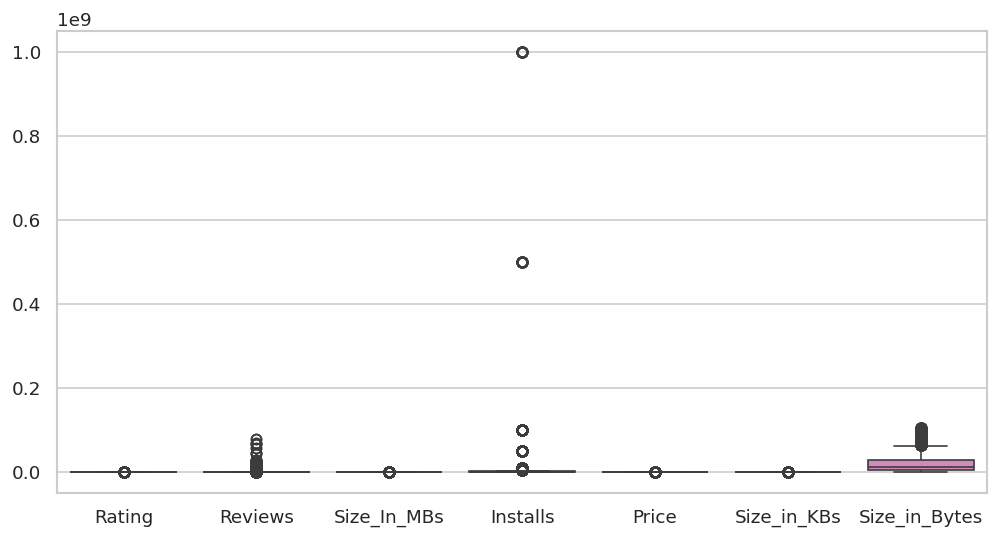

In [50]:
sns.boxplot(df)


📊 Processing Column: Rating
Rating → Minimum: 1.0
Rating → Q1: 4.0
Rating → Median: 4.3
Rating → Q3: 4.5
Rating → Maximum: 5.0
Rating → IQR: 0.5
Rating → Lower Bound: 3.25
Rating → Upper Bound: 5.25
Rating → Outliers Count: 495


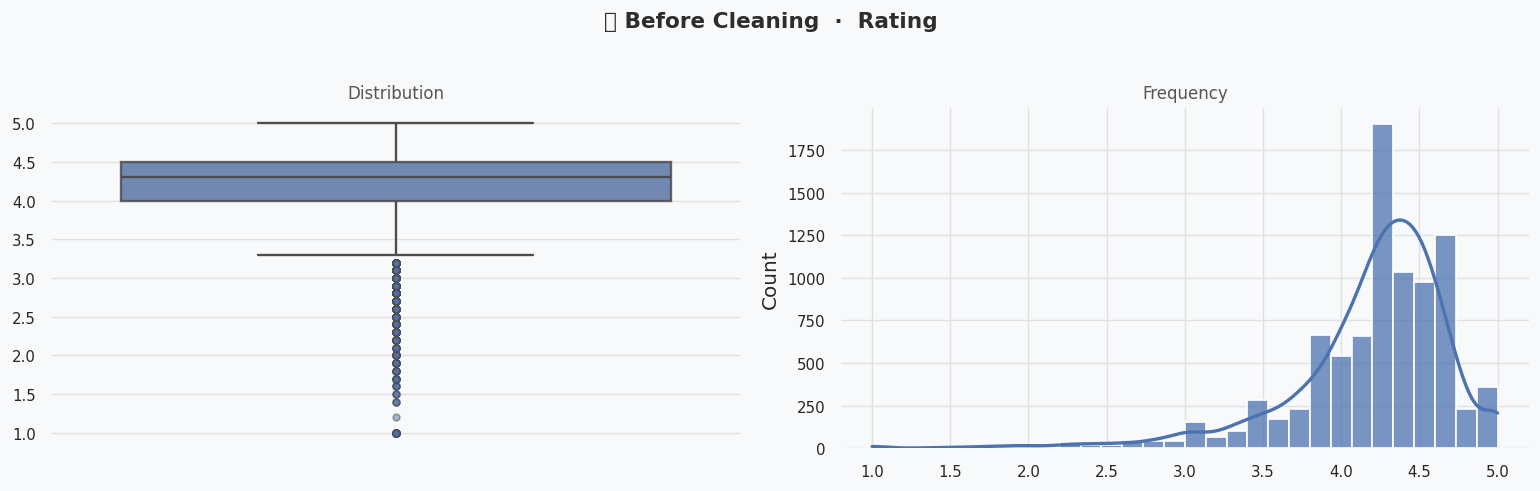

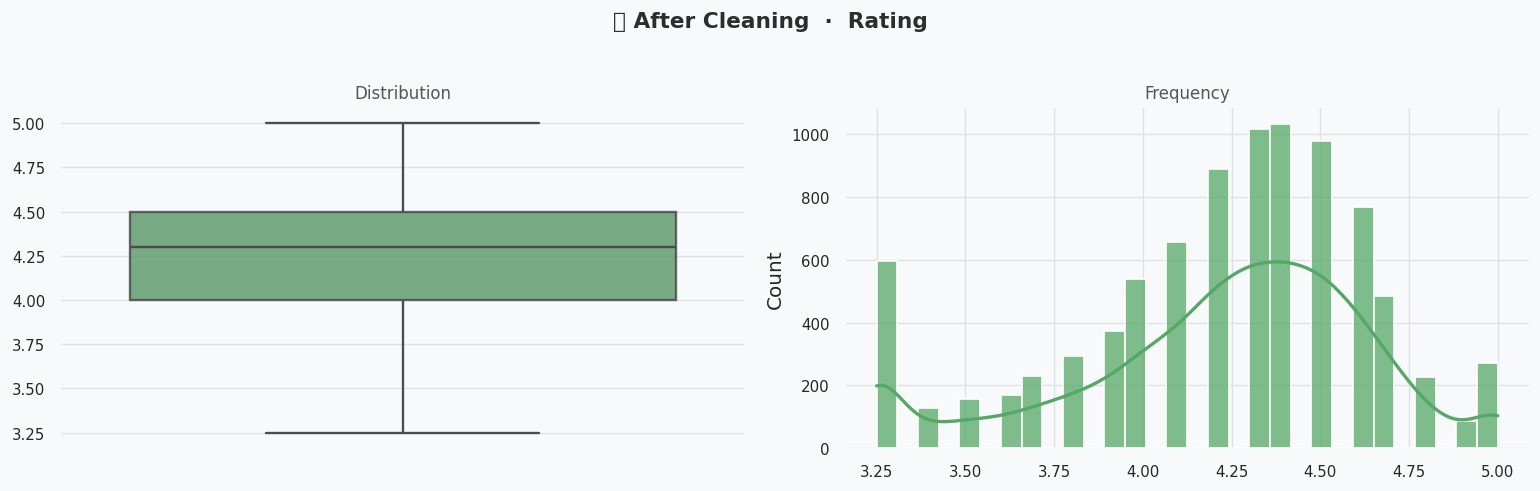


📊 Processing Column: Reviews
Reviews → Minimum: 0
Reviews → Q1: 32.0
Reviews → Median: 1680.0
Reviews → Q3: 46416.0
Reviews → Maximum: 78158306
Reviews → IQR: 46384.0
Reviews → Lower Bound: -69544.0
Reviews → Upper Bound: 115992.0
Reviews → Outliers Count: 1870


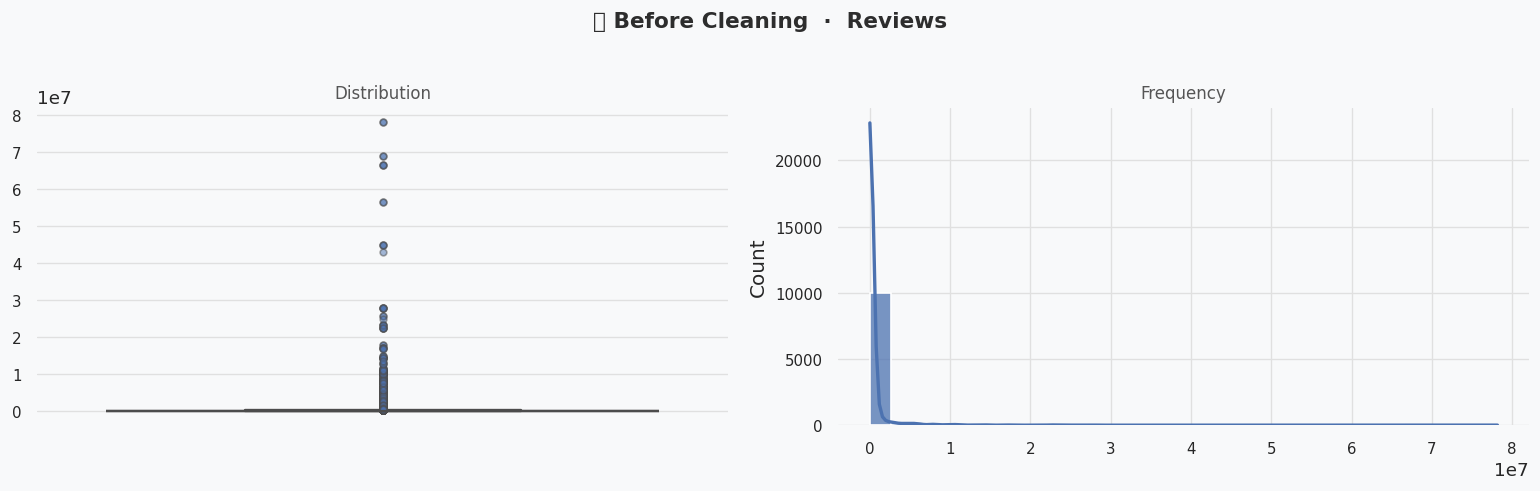

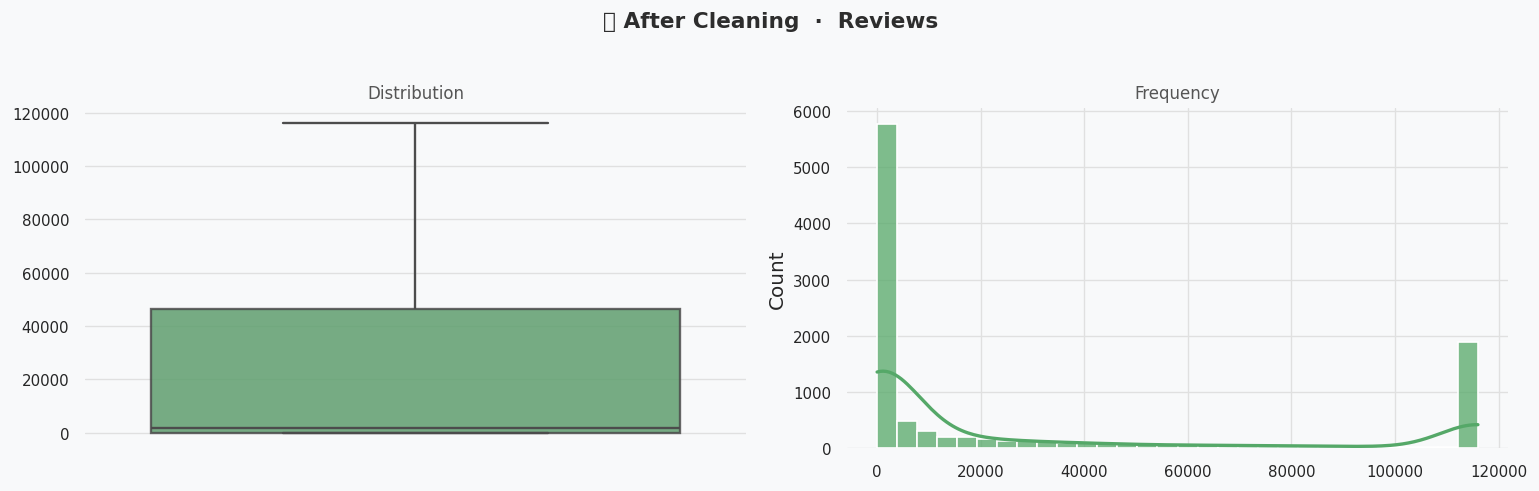


📊 Processing Column: Size_In_MBs
Size_In_MBs → Minimum: 0.00830078125
Size_In_MBs → Q1: 5.4
Size_In_MBs → Median: 12.0
Size_In_MBs → Q3: 27.0
Size_In_MBs → Maximum: 100.0
Size_In_MBs → IQR: 21.6
Size_In_MBs → Lower Bound: -27.000000000000007
Size_In_MBs → Upper Bound: 59.400000000000006
Size_In_MBs → Outliers Count: 738


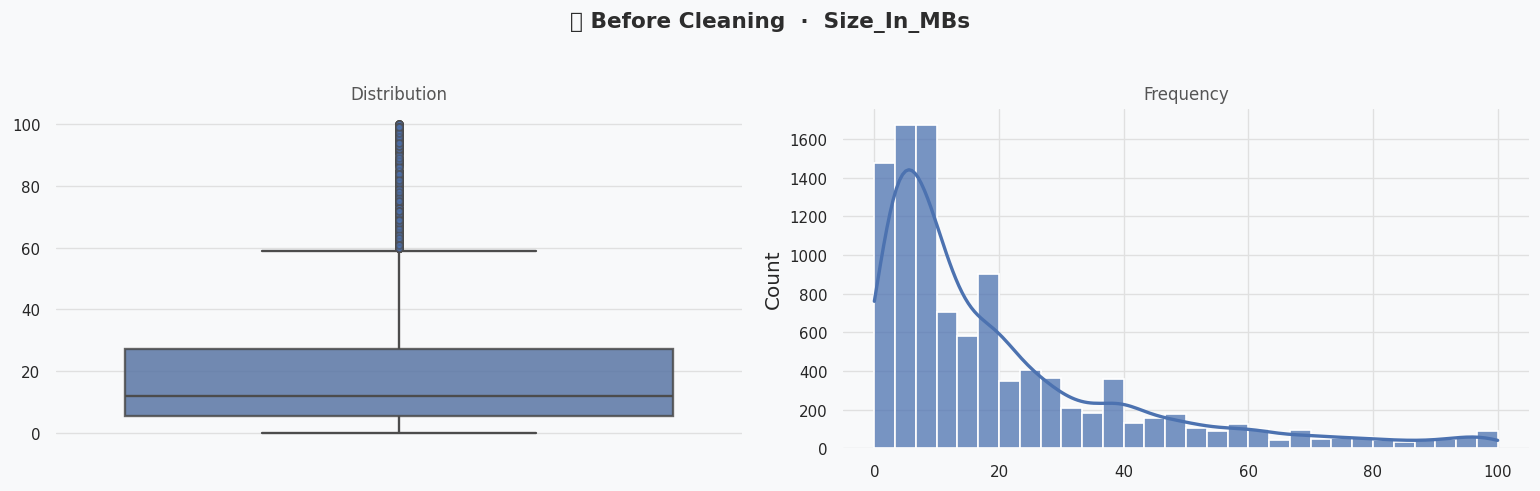

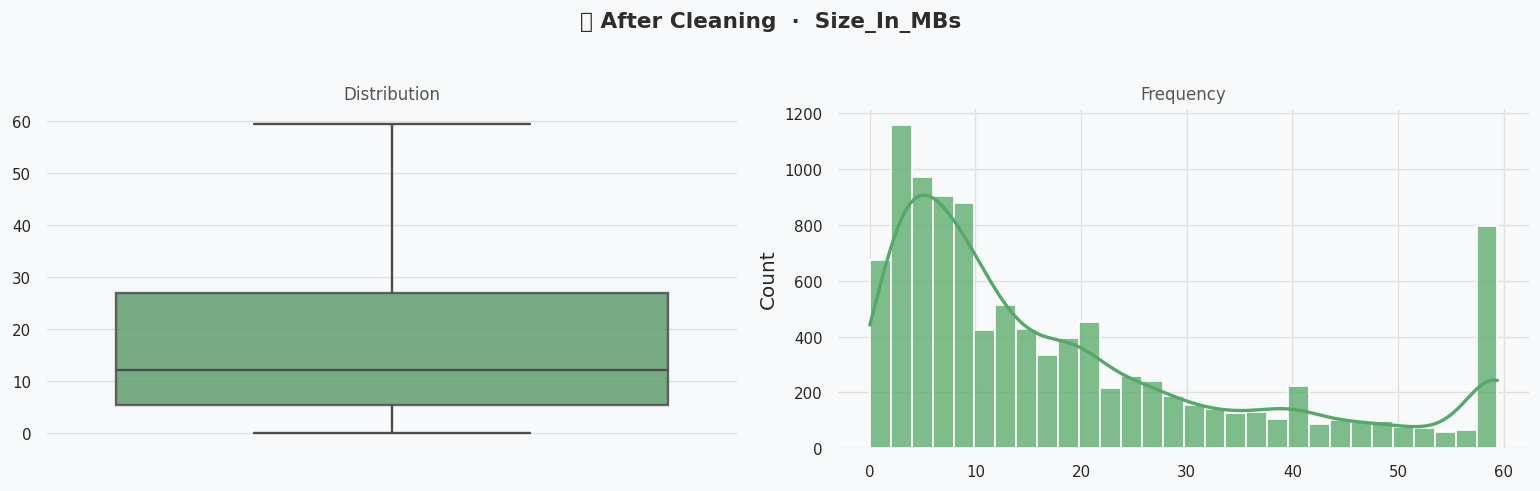


📊 Processing Column: Installs
Installs → Minimum: 0.0
Installs → Q1: 1000.0
Installs → Median: 100000.0
Installs → Q3: 1000000.0
Installs → Maximum: 1000000000.0
Installs → IQR: 999000.0
Installs → Lower Bound: -1497500.0
Installs → Upper Bound: 2498500.0
Installs → Outliers Count: 2566


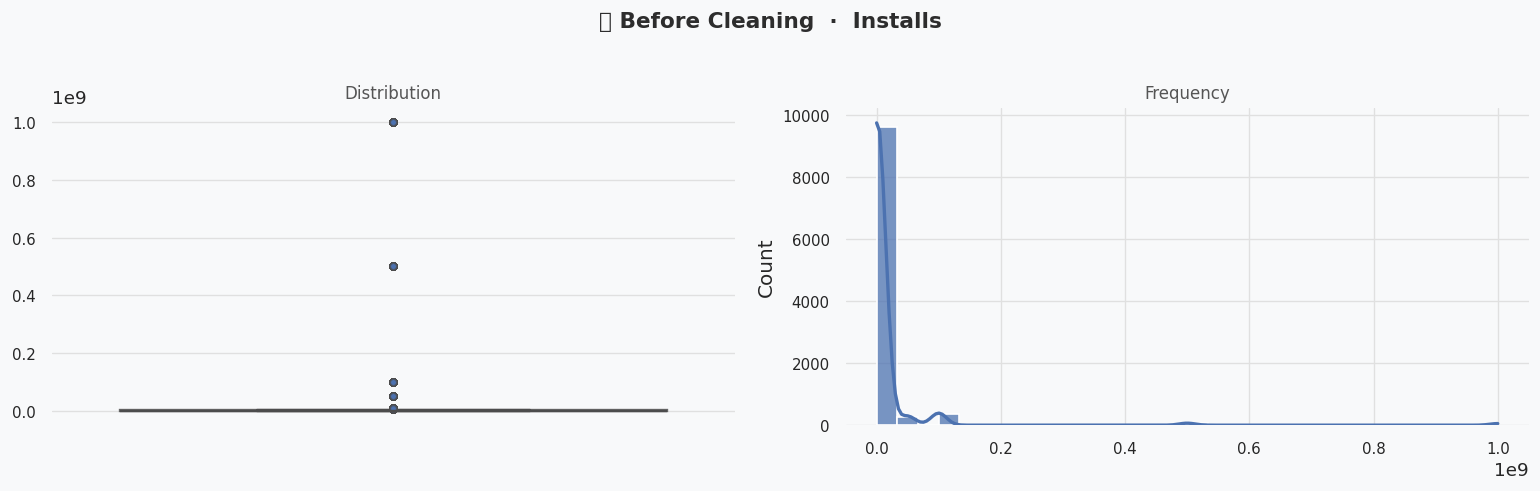

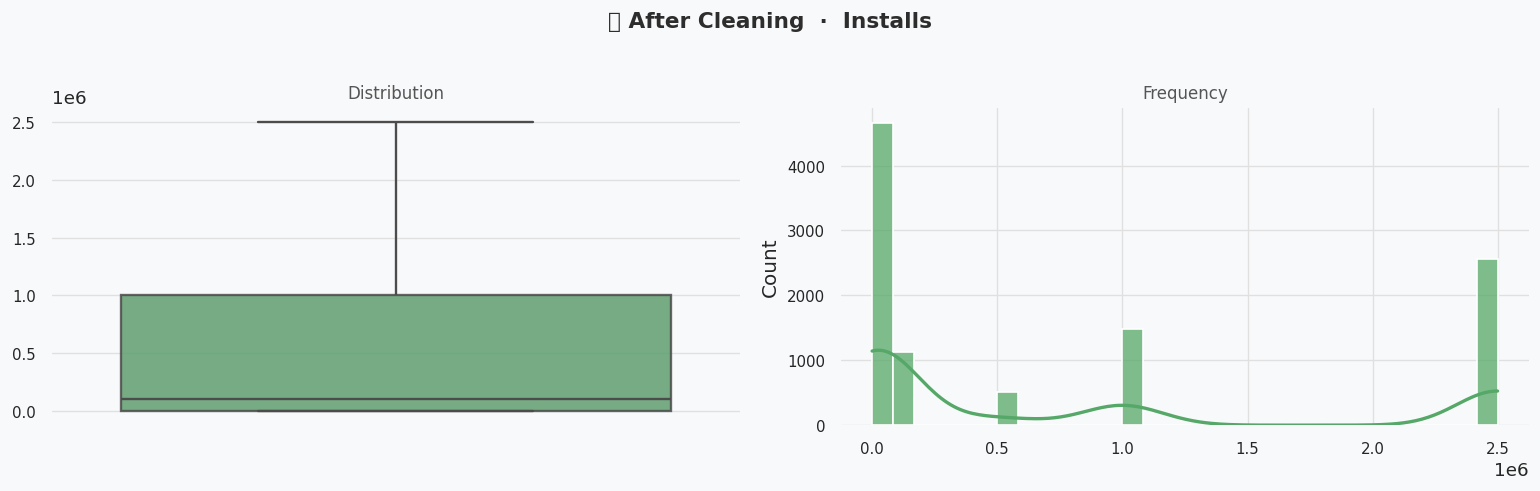


📊 Processing Column: Price
Price → Minimum: 0.0
Price → Q1: 0.0
Price → Median: 0.0
Price → Q3: 0.0
Price → Maximum: 400.0
Price → IQR: 0.0
Price → Lower Bound: 0.0
Price → Upper Bound: 0.0
Price → Outliers Count: 765


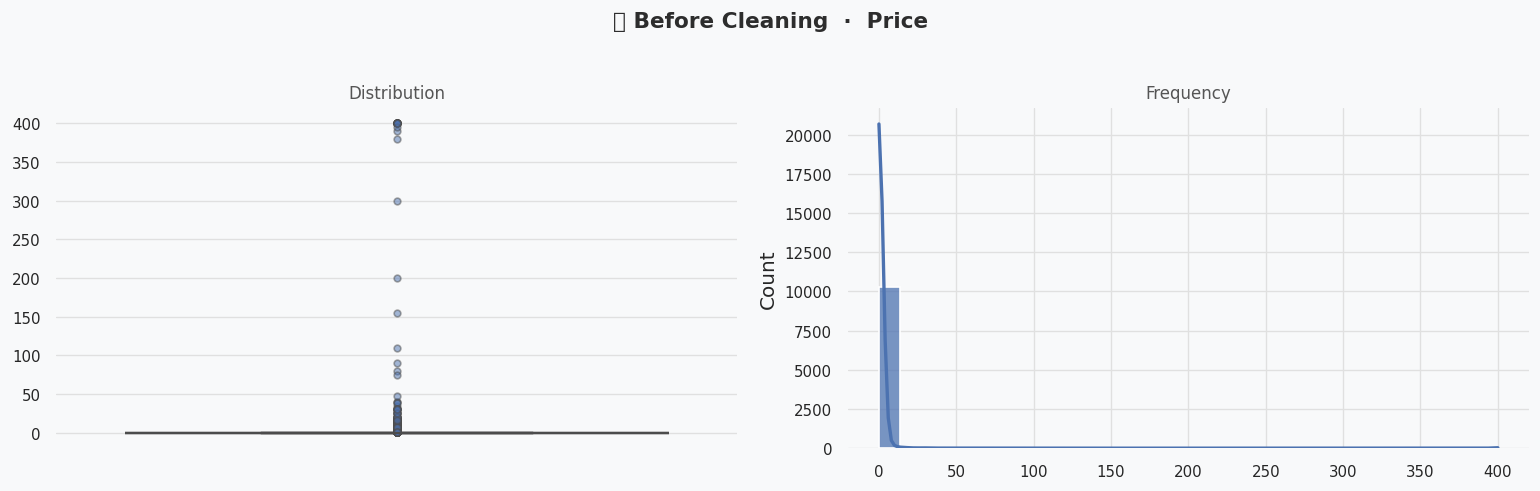

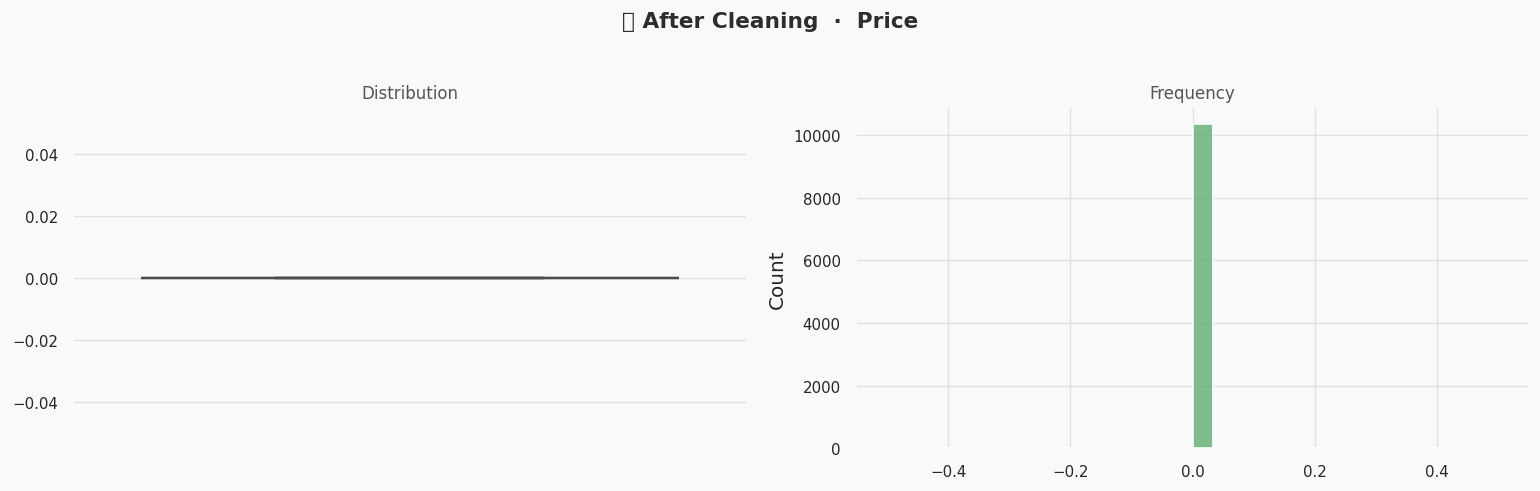


📊 Processing Column: Size_in_KBs
Size_in_KBs → Minimum: 8.5
Size_in_KBs → Q1: 5529.6
Size_in_KBs → Median: 12288.0
Size_in_KBs → Q3: 27648.0
Size_in_KBs → Maximum: 102400.0
Size_in_KBs → IQR: 22118.4
Size_in_KBs → Lower Bound: -27648.000000000007
Size_in_KBs → Upper Bound: 60825.600000000006
Size_in_KBs → Outliers Count: 738


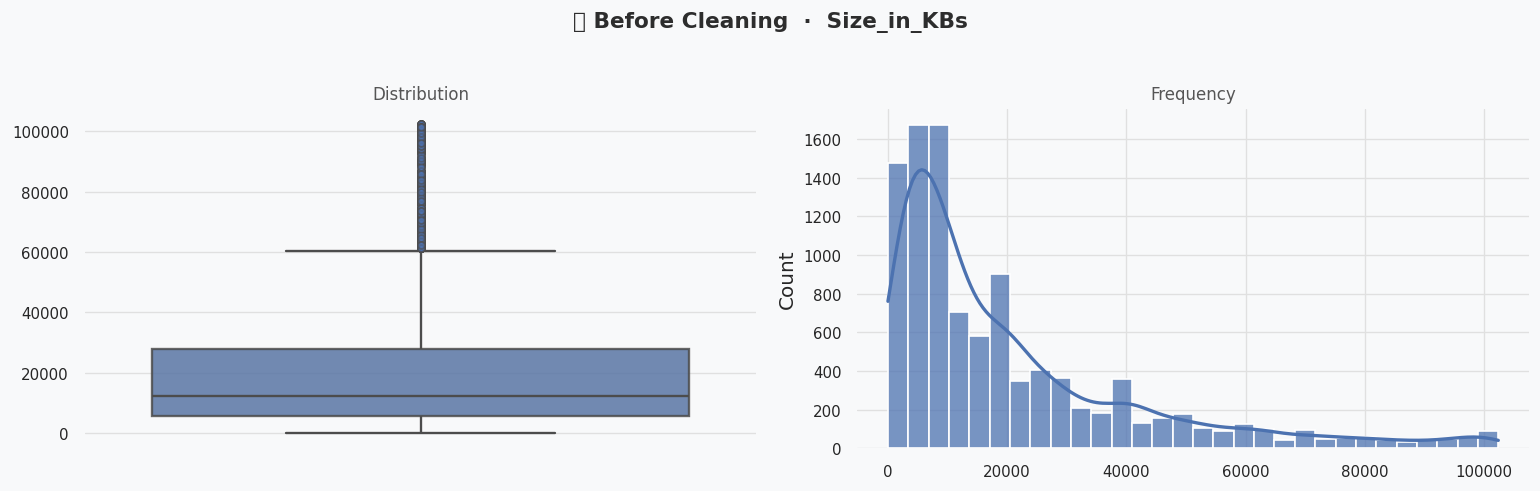

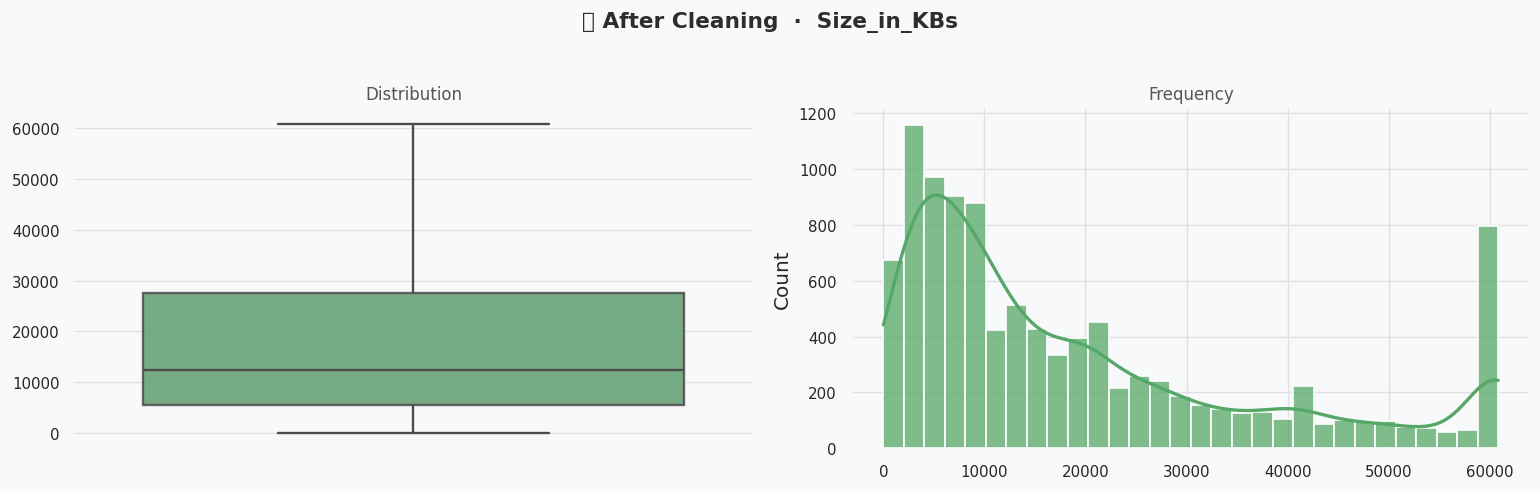


📊 Processing Column: Size_in_Bytes
Size_in_Bytes → Minimum: 8704.0
Size_in_Bytes → Q1: 5662310.4
Size_in_Bytes → Median: 12582912.0
Size_in_Bytes → Q3: 28311552.0
Size_in_Bytes → Maximum: 104857600.0
Size_in_Bytes → IQR: 22649241.6
Size_in_Bytes → Lower Bound: -28311552.000000007
Size_in_Bytes → Upper Bound: 62285414.400000006
Size_in_Bytes → Outliers Count: 738


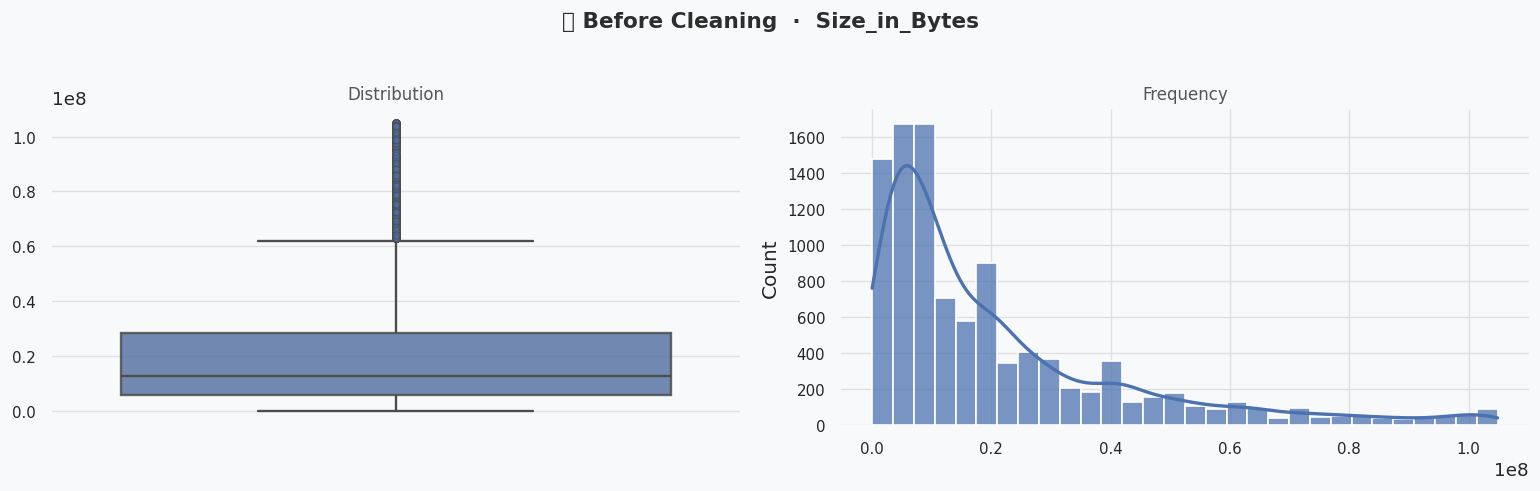

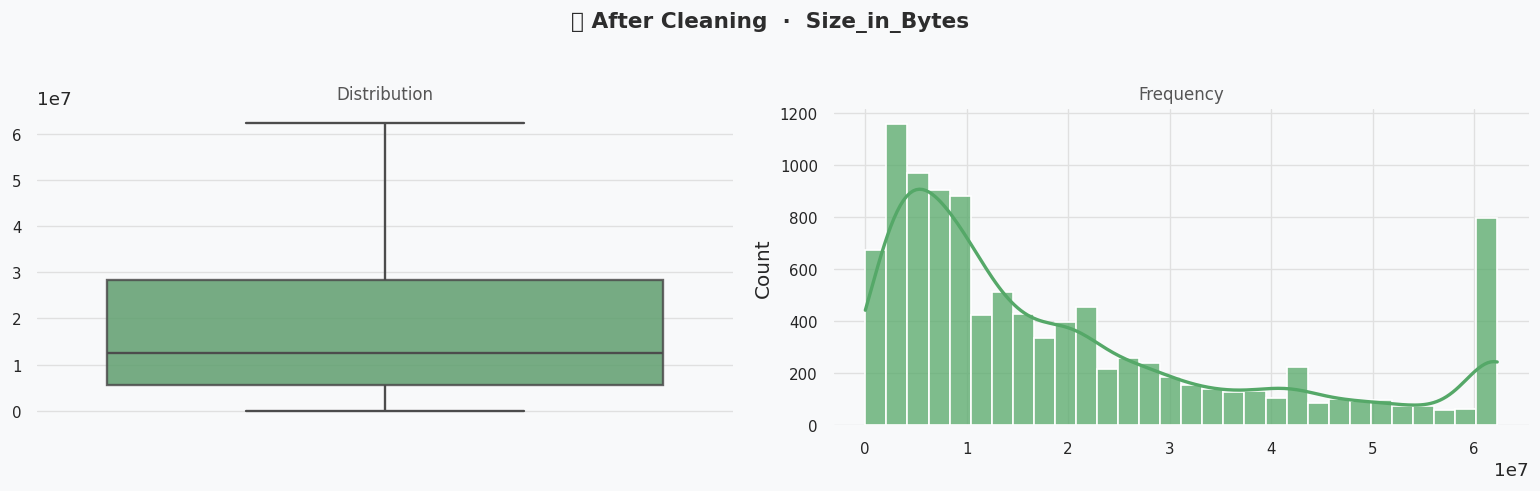

In [51]:
# Remove Count Outliers
def clean_data_from_outliers(col):
    data = df[col]

    print(f"\n{'='*50}")
    print(f"📊 Processing Column: {col}")
    print(f"{'='*50}")

    # 5-number summary
    minimum = data.min()
    q1 = data.quantile(0.25)
    median = data.median()
    q3 = data.quantile(0.75)
    maximum = data.max()

    print(f"{col} → Minimum: {minimum}")
    print(f"{col} → Q1: {q1}")
    print(f"{col} → Median: {median}")
    print(f"{col} → Q3: {q3}")
    print(f"{col} → Maximum: {maximum}")

    # IQR
    iqr = q3 - q1
    print(f"{col} → IQR: {iqr}")

    # Bounds
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    print(f"{col} → Lower Bound: {lower_bound}")
    print(f"{col} → Upper Bound: {upper_bound}")

    # Outliers
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    print(f"{col} → Outliers Count: {len(outliers)}")

    # ── Styling ──────────────────────────────────────────
    BEFORE_COLOR = "#4C72B0"
    AFTER_COLOR  = "#55A868"
    BG_COLOR     = "#F8F9FA"

    sns.set_style("whitegrid")
    plt.rcParams.update({
        "axes.facecolor":  BG_COLOR,
        "figure.facecolor": BG_COLOR,
        "axes.spines.top":    False,
        "axes.spines.right":  False,
        "axes.spines.left":   False,
        "axes.spines.bottom": False,
        "grid.color": "#E0E0E0",
        "grid.linewidth": 0.8,
    })

    def _plot_pair(series, color, label):
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        fig.patch.set_facecolor(BG_COLOR)
        fig.suptitle(
            f"{label}  ·  {col}",
            fontsize=13, fontweight="bold", color="#2d2d2d", y=1.02
        )

        # Boxplot
        sns.boxplot(
            y=series, ax=axes[0],
            color=color,
            linewidth=1.4,
            flierprops=dict(marker="o", markerfacecolor=color,
                            markersize=4, alpha=0.5, linestyle="none"),
            boxprops=dict(alpha=0.85),
        )
        axes[0].set_title("Distribution", fontsize=10, color="#555")
        axes[0].set_ylabel("")
        axes[0].tick_params(labelsize=9)

        # Histogram
        sns.histplot(
            series, kde=True, bins=30, ax=axes[1],
            color=color, alpha=0.75,
            line_kws={"linewidth": 2},
        )
        axes[1].set_title("Frequency", fontsize=10, color="#555")
        axes[1].set_xlabel("")
        axes[1].tick_params(labelsize=9)

        plt.tight_layout()
        plt.show()

    # 🔹 BEFORE
    _plot_pair(data, BEFORE_COLOR, "🔴 Before Cleaning")

    # Clean
    df[col] = data.clip(lower_bound, upper_bound)

    # 🔹 AFTER
    _plot_pair(df[col], AFTER_COLOR, "🟢 After Cleaning")


for col in df.select_dtypes(include="number").columns:
    clean_data_from_outliers(col)

<Axes: >

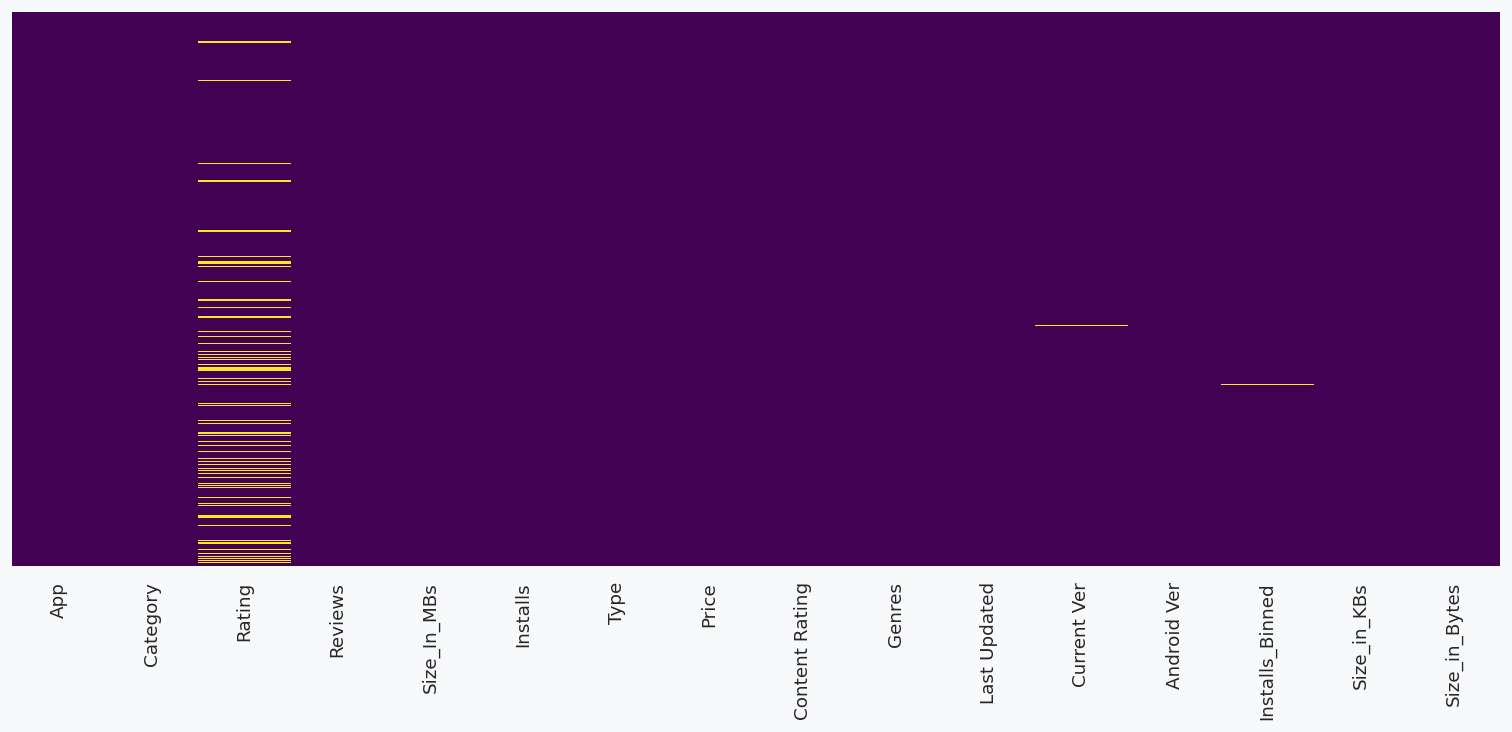

In [53]:
plt.figure(figsize=(16,6))

sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap="viridis")